## 1. Import necessary Libraries

In [18]:
pip install lightgbm

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'C:\Users\USER\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [80]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import AdaBoostClassifier,GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score,classification_report
import seaborn as sns
from matplotlib import pyplot as plt


## 2. Load the data

In [5]:
credit_card_data=pd.read_csv("credit_card_clean.csv")
credit_card_data

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
0,1,20000.0,female,university,married,24,2,2,-1,-1,-2,-2,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,female,university,single,26,-1,2,0,0,0,2,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,female,university,single,34,0,0,0,0,0,0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,female,university,married,37,0,0,0,0,0,0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,male,university,married,57,-1,0,-1,0,0,0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,220000.0,male,highschool,married,39,0,0,0,0,0,0,188948.0,192815.0,208365.0,88004.0,31237.0,15980.0,8500.0,20000.0,5003.0,3047.0,5000.0,1000.0,0
29996,29997,150000.0,male,highschool,single,43,-1,-1,-1,-1,0,0,1683.0,1828.0,3502.0,8979.0,5190.0,0.0,1837.0,3526.0,8998.0,129.0,0.0,0.0,0
29997,29998,30000.0,male,university,single,37,4,3,2,-1,0,0,3565.0,3356.0,2758.0,20878.0,20582.0,19357.0,0.0,0.0,22000.0,4200.0,2000.0,3100.0,1
29998,29999,80000.0,male,highschool,married,41,1,-1,0,0,0,-1,-1645.0,78379.0,76304.0,52774.0,11855.0,48944.0,85900.0,3409.0,1178.0,1926.0,52964.0,1804.0,1


## 3. Data understanding

Exploring the variable
ID : ID of each client

LIMIT_BAL: Amount of given credit in NT dollars (includes individual and family/supplementary credit)

SEX: Gender (1=male, 2=female)

EDUCATION: (1=graduate school, 2=university, 3=high school, 4=others, 5=unknown, 6=unknown)

MARRIAGE: Marital status (1=married, 2=single, 3=others)

AGE: Age in years

PAY_1: Repayment status in September, 2005 (-2 = No consumption, -1 = paid in full, 0 = use of revolving credit (paid minimum only), 1 = payment delay for one month, 2 = payment delay for two months, ... 8 = payment delay for eight months, 9 = payment delay for nine months and above)

PAY_2: Repayment status in August, 2005 (scale same as above)

PAY_3: Repayment status in July, 2005 (scale same as above)

PAY_4: Repayment status in June, 2005 (scale same as above)

PAY_5: Repayment status in May, 2005 (scale same as above)

PAY_6: Repayment status in April, 2005 (scale same as above)

BILL_AMT1: Amount of bill statement in September, 2005 (NT dollar)

BILL_AMT2: Amount of bill statement in August, 2005 (NT dollar)

BILL_AMT3: Amount of bill statement in July, 2005 (NT dollar)

BILL_AMT4: Amount of bill statement in June, 2005 (NT dollar)

BILL_AMT5: Amount of bill statement in May, 2005 (NT dollar)

BILL_AMT6: Amount of bill statement in April, 2005 (NT dollar)

PAY_AMT1: Amount of previous payment in September, 2005 (NT dollar)

PAY_AMT2: Amount of previous payment in August, 2005 (NT dollar)

PAY_AMT3: Amount of previous payment in July, 2005 (NT dollar)

PAY_AMT4: Amount of previous payment in June, 2005 (NT dollar)

PAY_AMT5: Amount of previous payment in May, 2005 (NT dollar)

PAY_AMT6: Amount of previous payment in April, 2005 (NT dollar)

Target variable
default.payment.next.month: Default payment (1=yes, 0=no)

Note: NT is Taiwain Dollars

In [6]:
credit_card_data.shape

(30000, 25)

In [7]:
credit_card_data.isna().sum()

ID           0
LIMIT_BAL    0
SEX          0
EDUCATION    0
MARRIAGE     0
AGE          0
PAY_1        0
PAY_2        0
PAY_3        0
PAY_4        0
PAY_5        0
PAY_6        0
BILL_AMT1    0
BILL_AMT2    0
BILL_AMT3    0
BILL_AMT4    0
BILL_AMT5    0
BILL_AMT6    0
PAY_AMT1     0
PAY_AMT2     0
PAY_AMT3     0
PAY_AMT4     0
PAY_AMT5     0
PAY_AMT6     0
DEFAULT      0
dtype: int64

In [8]:
credit_card_data.dtypes

ID             int64
LIMIT_BAL    float64
SEX           object
EDUCATION     object
MARRIAGE      object
AGE            int64
PAY_1          int64
PAY_2          int64
PAY_3          int64
PAY_4          int64
PAY_5          int64
PAY_6          int64
BILL_AMT1    float64
BILL_AMT2    float64
BILL_AMT3    float64
BILL_AMT4    float64
BILL_AMT5    float64
BILL_AMT6    float64
PAY_AMT1     float64
PAY_AMT2     float64
PAY_AMT3     float64
PAY_AMT4     float64
PAY_AMT5     float64
PAY_AMT6     float64
DEFAULT        int64
dtype: object

## 4. Data Preprocessing / Data Preparation

* 1. There is no null values and hence no need to perform any imputations like mean or median or mode
* 2. We need to remove few columns which is not needed
* 3. We need to perform the data transformation for the features(SEX,EDUCATION,MARRIAGE)

In [9]:
credit_card_data.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
0,1,20000.0,female,university,married,24,2,2,-1,-1,-2,-2,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,female,university,single,26,-1,2,0,0,0,2,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,female,university,single,34,0,0,0,0,0,0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,female,university,married,37,0,0,0,0,0,0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,male,university,married,57,-1,0,-1,0,0,0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [11]:
credit_card_data.drop(labels="ID",axis=1,inplace=True)

In [12]:
credit_card_data

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
0,20000.0,female,university,married,24,2,2,-1,-1,-2,-2,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,120000.0,female,university,single,26,-1,2,0,0,0,2,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,90000.0,female,university,single,34,0,0,0,0,0,0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,50000.0,female,university,married,37,0,0,0,0,0,0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,50000.0,male,university,married,57,-1,0,-1,0,0,0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000.0,male,highschool,married,39,0,0,0,0,0,0,188948.0,192815.0,208365.0,88004.0,31237.0,15980.0,8500.0,20000.0,5003.0,3047.0,5000.0,1000.0,0
29996,150000.0,male,highschool,single,43,-1,-1,-1,-1,0,0,1683.0,1828.0,3502.0,8979.0,5190.0,0.0,1837.0,3526.0,8998.0,129.0,0.0,0.0,0
29997,30000.0,male,university,single,37,4,3,2,-1,0,0,3565.0,3356.0,2758.0,20878.0,20582.0,19357.0,0.0,0.0,22000.0,4200.0,2000.0,3100.0,1
29998,80000.0,male,highschool,married,41,1,-1,0,0,0,-1,-1645.0,78379.0,76304.0,52774.0,11855.0,48944.0,85900.0,3409.0,1178.0,1926.0,52964.0,1804.0,1


In [ ]:
# Data Transformation

In [24]:
le=LabelEncoder()
credit_card_data["SEX"]=le.fit_transform(y=credit_card_data["SEX"])
credit_card_data["EDUCATION"]=le.fit_transform(y=credit_card_data["EDUCATION"])
credit_card_data["MARRIAGE"]=le.fit_transform(y=credit_card_data["MARRIAGE"])
credit_card_data

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
0,20000.0,0,3,0,24,2,2,-1,-1,-2,-2,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,120000.0,0,3,2,26,-1,2,0,0,0,2,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,90000.0,0,3,2,34,0,0,0,0,0,0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,50000.0,0,3,0,37,0,0,0,0,0,0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,50000.0,1,3,0,57,-1,0,-1,0,0,0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000.0,1,1,0,39,0,0,0,0,0,0,188948.0,192815.0,208365.0,88004.0,31237.0,15980.0,8500.0,20000.0,5003.0,3047.0,5000.0,1000.0,0
29996,150000.0,1,1,2,43,-1,-1,-1,-1,0,0,1683.0,1828.0,3502.0,8979.0,5190.0,0.0,1837.0,3526.0,8998.0,129.0,0.0,0.0,0
29997,30000.0,1,3,2,37,4,3,2,-1,0,0,3565.0,3356.0,2758.0,20878.0,20582.0,19357.0,0.0,0.0,22000.0,4200.0,2000.0,3100.0,1
29998,80000.0,1,1,0,41,1,-1,0,0,0,-1,-1645.0,78379.0,76304.0,52774.0,11855.0,48944.0,85900.0,3409.0,1178.0,1926.0,52964.0,1804.0,1


In [25]:
# split the X and y
X=credit_card_data.drop(labels="DEFAULT",axis=1)
X

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
0,20000.0,0,3,0,24,2,2,-1,-1,-2,-2,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0
1,120000.0,0,3,2,26,-1,2,0,0,0,2,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0
2,90000.0,0,3,2,34,0,0,0,0,0,0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0
3,50000.0,0,3,0,37,0,0,0,0,0,0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0
4,50000.0,1,3,0,57,-1,0,-1,0,0,0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000.0,1,1,0,39,0,0,0,0,0,0,188948.0,192815.0,208365.0,88004.0,31237.0,15980.0,8500.0,20000.0,5003.0,3047.0,5000.0,1000.0
29996,150000.0,1,1,2,43,-1,-1,-1,-1,0,0,1683.0,1828.0,3502.0,8979.0,5190.0,0.0,1837.0,3526.0,8998.0,129.0,0.0,0.0
29997,30000.0,1,3,2,37,4,3,2,-1,0,0,3565.0,3356.0,2758.0,20878.0,20582.0,19357.0,0.0,0.0,22000.0,4200.0,2000.0,3100.0
29998,80000.0,1,1,0,41,1,-1,0,0,0,-1,-1645.0,78379.0,76304.0,52774.0,11855.0,48944.0,85900.0,3409.0,1178.0,1926.0,52964.0,1804.0


In [26]:
y=credit_card_data["DEFAULT"]
y

0        1
1        1
2        0
3        0
4        0
        ..
29995    0
29996    0
29997    1
29998    1
29999    1
Name: DEFAULT, Length: 30000, dtype: int64

## 5. Model Building

In [29]:
ada_boost_classifier=AdaBoostClassifier(n_estimators=50)
gradient_boost_classifier=GradientBoostingClassifier(n_estimators=50)
xgb_classifier=XGBClassifier(n_estimators=50)
lgb_classifier=LGBMClassifier(n_estimators=50)

In [30]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,shuffle=True,random_state=123,stratify=y)

In [32]:
print("Training data:", X_train.shape,y_train.shape)
print("Test data:",X_test.shape,y_test.shape)

Training data: (24000, 23) (24000,)
Test data: (6000, 23) (6000,)


## 6. Model Training

In [34]:
%%time
ada_boost_classifier.fit(X_train,y_train)

CPU times: total: 2.52 s
Wall time: 2.54 s


,estimator,None
,n_estimators,50
,learning_rate,1.0
,algorithm,'deprecated'
,random_state,None


In [35]:
%%time
gradient_boost_classifier.fit(X_train,y_train)

CPU times: total: 6.08 s
Wall time: 6.17 s


,loss,'log_loss'
,learning_rate,0.1
,n_estimators,50
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [38]:
%%time
xgb_classifier.fit(X_train,y_train)


CPU times: total: 1.09 s
Wall time: 370 ms


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [39]:
%%time
lgb_classifier.fit(X_train,y_train)

[LightGBM] [Info] Number of positive: 5309, number of negative: 18691
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001198 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3259
[LightGBM] [Info] Number of data points in the train set: 24000, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.221208 -> initscore=-1.258639
[LightGBM] [Info] Start training from score -1.258639
CPU times: total: 625 ms
Wall time: 328 ms


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,50
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


## 7. Model Testing || 8. Model Evaluation

### Training dataset

In [44]:
# adaboost
y_pred_train_ab=ada_boost_classifier.predict(X_train)

In [63]:
# Evaluation
print("Classification Report:\n",classification_report(y_train,y_pred_train_ab))
print("Confusion Matrix:\n",confusion_matrix(y_train,y_pred_train_ab))
print("Accuracy_Score:",accuracy_score(y_train,y_pred_train_ab))
print("Precision_Score:",precision_score(y_train,y_pred_train_ab))
print("Recall_Score:",recall_score(y_train,y_pred_train_ab))


Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.96      0.89     18691
           1       0.68      0.33      0.45      5309

    accuracy                           0.82     24000
   macro avg       0.76      0.64      0.67     24000
weighted avg       0.80      0.82      0.79     24000

Confusion Matrix:
 [[17876   815]
 [ 3539  1770]]
Accuracy_Score: 0.8185833333333333
Precision_Score: 0.6847195357833655
Recall_Score: 0.33339611979657185


In [48]:
# GradientBoosting
y_pred_train_gb=gradient_boost_classifier.predict(X_train)

In [49]:
# Evaluation
print("Confusion Matrix:\n",confusion_matrix(y_train,y_pred_train_gb))
print("Accuracy_Score:",accuracy_score(y_train,y_pred_train_gb))
print("Precision_Score:",precision_score(y_train,y_pred_train_gb))
print("Recall_Score:",recall_score(y_train,y_pred_train_gb))


Confusion Matrix:
 [[17801   890]
 [ 3345  1964]]
Accuracy_Score: 0.8235416666666666
Precision_Score: 0.6881569726699369
Recall_Score: 0.36993784140139385


In [50]:
# XGBOOST
y_pred_train_xgb=xgb_classifier.predict(X_train)

In [51]:
# Evaluation
print("Confusion Matrix:\n",confusion_matrix(y_train,y_pred_train_xgb))
print("Accuracy_Score:",accuracy_score(y_train,y_pred_train_xgb))
print("Precision_Score:",precision_score(y_train,y_pred_train_xgb))
print("Recall_Score:",recall_score(y_train,y_pred_train_xgb))

Confusion Matrix:
 [[18129   562]
 [ 2722  2587]]
Accuracy_Score: 0.8631666666666666
Precision_Score: 0.821530644649095
Recall_Score: 0.48728574119419854


In [52]:
# LGBM
y_pred_train_lgbm=lgb_classifier.predict(X_train)

In [54]:
# Evaluation
print("Confusion Matrix:\n",confusion_matrix(y_train,y_pred_train_lgbm))
print("Accuracy_Score:",accuracy_score(y_train,y_pred_train_lgbm))
print("Precision_Score:",precision_score(y_train,y_pred_train_lgbm))
print("Recall_Score:",recall_score(y_train,y_pred_train_lgbm))

Confusion Matrix:
 [[17880   811]
 [ 3217  2092]]
Accuracy_Score: 0.8321666666666667
Precision_Score: 0.7206338270754392
Recall_Score: 0.39404784328498776


### Test dataset

In [55]:
# adaboost
y_pred_test_ab=ada_boost_classifier.predict(X_test)

In [57]:
# Evaluation
print("Confusion Matrix:\n",confusion_matrix(y_test,y_pred_test_ab))
print("Accuracy_Score:",accuracy_score(y_test,y_pred_test_ab))
print("Precision_Score:",precision_score(y_test,y_pred_test_ab))
print("Recall_Score:",recall_score(y_test,y_pred_test_ab))


Confusion Matrix:
 [[4487  186]
 [ 883  444]]
Accuracy_Score: 0.8218333333333333
Precision_Score: 0.7047619047619048
Recall_Score: 0.33458929917106256


In [58]:
# GradientBoosting
y_pred_test_gb=gradient_boost_classifier.predict(X_test)
# Evaluation
print("Confusion Matrix:\n",confusion_matrix(y_test,y_pred_test_gb))
print("Accuracy_Score:",accuracy_score(y_test,y_pred_test_gb))
print("Precision_Score:",precision_score(y_test,y_pred_test_gb))
print("Recall_Score:",recall_score(y_test,y_pred_test_gb))

Confusion Matrix:
 [[4464  209]
 [ 851  476]]
Accuracy_Score: 0.8233333333333334
Precision_Score: 0.6948905109489051
Recall_Score: 0.35870384325546345


In [59]:
# XGBoost
y_pred_test_xgb=xgb_classifier.predict(X_test)
# Evaluation
print("Confusion Matrix:\n",confusion_matrix(y_test,y_pred_test_xgb))
print("Accuracy_Score:",accuracy_score(y_test,y_pred_test_xgb))
print("Precision_Score:",precision_score(y_test,y_pred_test_xgb))
print("Recall_Score:",recall_score(y_test,y_pred_test_xgb))

Confusion Matrix:
 [[4424  249]
 [ 836  491]]
Accuracy_Score: 0.8191666666666667
Precision_Score: 0.6635135135135135
Recall_Score: 0.3700075357950264


In [61]:
# LGBM
y_pred_test_lgbm=lgb_classifier.predict(X_test)
# Evaluation
print("Confusion Matrix:\n",confusion_matrix(y_test,y_pred_test_lgbm))
print("Accuracy_Score:",accuracy_score(y_test,y_pred_test_lgbm))
print("Precision_Score:",precision_score(y_test,y_pred_test_lgbm))
print("Recall_Score:",recall_score(y_test,y_pred_test_lgbm))

Confusion Matrix:
 [[4459  214]
 [ 837  490]]
Accuracy_Score: 0.8248333333333333
Precision_Score: 0.6960227272727273
Recall_Score: 0.36925395629238883


## Feature Importance

In [68]:
ada_boost_features=ada_boost_classifier.feature_importances_

In [69]:
gradient_boost_features=gradient_boost_classifier.feature_importances_

In [70]:
xgb_features=xgb_classifier.feature_importances_

In [71]:
lgb_features=lgb_classifier.feature_importances_

In [75]:
feature_importance_df=pd.DataFrame(data={"Features":X.columns,
                   "AdaBoost_Features":ada_boost_features,
                   "GradientBoost_Features":gradient_boost_features,
                   "XGB_Features":xgb_features,
                   "LGB_Features":lgb_features})

In [83]:
ada_boost_sorted=feature_importance_df.sort_values(by="AdaBoost_Features",ascending=False)
ada_boost_sorted

,Features,AdaBoost_Features,GradientBoost_Features,XGB_Features,LGB_Features
5,PAY_1,0.513985,0.655314,0.441974,67
17,PAY_AMT1,0.087824,0.021428,0.020004,78
18,PAY_AMT2,0.064727,0.017985,0.020352,97
0,LIMIT_BAL,0.057269,0.026852,0.021445,114
7,PAY_3,0.052493,0.041462,0.056258,41
10,PAY_6,0.042327,0.018469,0.030770,42
19,PAY_AMT3,0.037968,0.020130,0.022179,86
6,PAY_2,0.035080,0.093329,0.086859,32
20,PAY_AMT4,0.019563,0.010408,0.019078,76
15,BILL_AMT5,0.018466,0.002390,0.015548,69


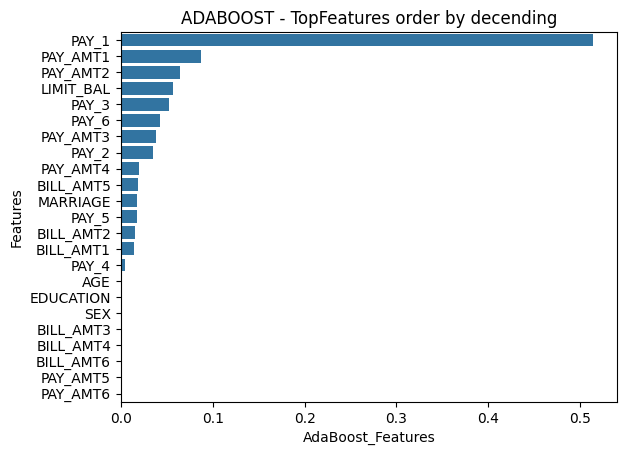

In [86]:
sns.barplot(data=ada_boost_sorted,x="AdaBoost_Features",y="Features")
plt.title("ADABOOST - TopFeatures order by decending")
plt.show()

In [87]:
gradient_boost_sorted=feature_importance_df.sort_values(by="GradientBoost_Features",ascending=False)
gradient_boost_sorted

,Features,AdaBoost_Features,GradientBoost_Features,XGB_Features,LGB_Features
5,PAY_1,0.513985,0.655314,0.441974,67
6,PAY_2,0.035080,0.093329,0.086859,32
7,PAY_3,0.052493,0.041462,0.056258,41
0,LIMIT_BAL,0.057269,0.026852,0.021445,114
11,BILL_AMT1,0.014796,0.022708,0.020663,133
17,PAY_AMT1,0.087824,0.021428,0.020004,78
19,PAY_AMT3,0.037968,0.020130,0.022179,86
10,PAY_6,0.042327,0.018469,0.030770,42
18,PAY_AMT2,0.064727,0.017985,0.020352,97
8,PAY_4,0.004686,0.016415,0.053257,23


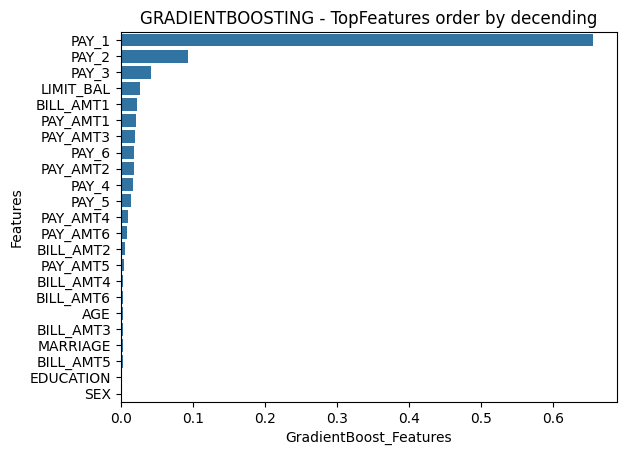

In [88]:
sns.barplot(data=gradient_boost_sorted,x="GradientBoost_Features",y="Features")
plt.title("GRADIENTBOOSTING - TopFeatures order by decending")
plt.show()

In [89]:
xgb_sorted=feature_importance_df.sort_values(by="XGB_Features",ascending=False)
xgb_sorted

,Features,AdaBoost_Features,GradientBoost_Features,XGB_Features,LGB_Features
5,PAY_1,0.513985,0.655314,0.441974,67
6,PAY_2,0.035080,0.093329,0.086859,32
7,PAY_3,0.052493,0.041462,0.056258,41
8,PAY_4,0.004686,0.016415,0.053257,23
9,PAY_5,0.017710,0.013692,0.034210,26
10,PAY_6,0.042327,0.018469,0.030770,42
19,PAY_AMT3,0.037968,0.020130,0.022179,86
0,LIMIT_BAL,0.057269,0.026852,0.021445,114
11,BILL_AMT1,0.014796,0.022708,0.020663,133
18,PAY_AMT2,0.064727,0.017985,0.020352,97


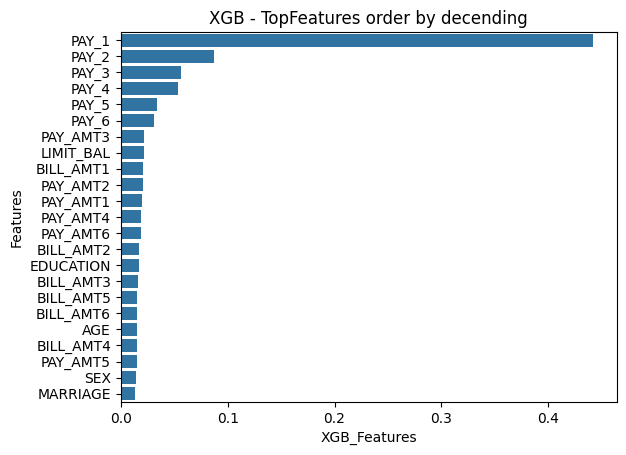

In [90]:
sns.barplot(data=xgb_sorted,x="XGB_Features",y="Features")
plt.title("XGB - TopFeatures order by decending")
plt.show()

In [91]:
lgb_sorted=feature_importance_df.sort_values(by="LGB_Features",ascending=False)
lgb_sorted

,Features,AdaBoost_Features,GradientBoost_Features,XGB_Features,LGB_Features
11,BILL_AMT1,0.014796,0.022708,0.020663,133
0,LIMIT_BAL,0.057269,0.026852,0.021445,114
22,PAY_AMT6,0.000000,0.008694,0.018519,102
18,PAY_AMT2,0.064727,0.017985,0.020352,97
4,AGE,0.000000,0.003232,0.015188,93
19,PAY_AMT3,0.037968,0.020130,0.022179,86
17,PAY_AMT1,0.087824,0.021428,0.020004,78
20,PAY_AMT4,0.019563,0.010408,0.019078,76
13,BILL_AMT3,0.000000,0.002958,0.016355,76
14,BILL_AMT4,0.000000,0.003331,0.015089,73


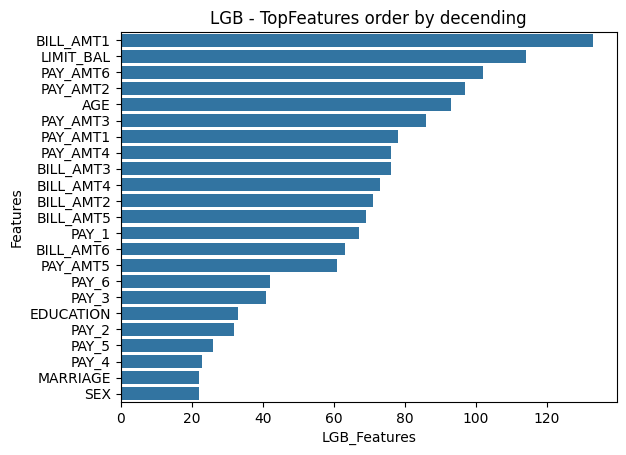

In [92]:
sns.barplot(data=lgb_sorted,x="LGB_Features",y="Features")
plt.title("LGB - TopFeatures order by decending")
plt.show()

## THE END!